In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}

div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

<font size="5" color="red">2.한글 형태 분석</font>
# 1. 자연어처리
-자연어 : 일상적인 언어
-자연어 처리 분야:
-자연어 이해 : 형태소분석 -> postagging -> 의미분석, 시각화
-자연어 생성 : RNN, LSTM, GRU, ... , encoder-decoder알고리즘 -> 트랜스포머알고리즘
-활용분야 : 트랜드분석, 탐색적 분석, 맞춤법검사, 번역기, 쳇봇
# 2. 자연어 이해 처리 절차
-전처리 : 단어, 어절 추출
-분석 후보 생성 : 형태소 분리, 품사태깅(pos tagging)
-제약조건(불용어 처리) : 규칙 확인
-분석 : 시각화(워드클라우드), 연관분석, RNN, LSTM, GRU, ...
# 한글형태소 분석 엔진

- konlpy (pip install konpy)
    * HanNanum: 자바로 만든 형태소 분석기
    * Kkma
    * Komoran
    * OKt
 - MEcab

In [2]:
import os
os.environ.get('JAVA_HOME')

'C:\\Program Files\\Java\\jdk-17'

In [3]:
text = ''' 아름답지만 다소 복잡하기도 한 한국어는 전 세계에서 13번째로 사용되는 언어입니다
''' 

In [4]:
from konlpy.tag import Hannanum
hannanum = Hannanum(jvmpath=None,
                  max_heap_size=1024)
hannanum.analyze(text)

[[[('아름답', 'paa'), ('지만', 'ecs')],
  [('아름답', 'paa'), ('지', 'ecs'), ('만', 'jxc')],
  [('아름답', 'paa'), ('지', 'ecx'), ('말', 'px'), ('ㄴ', 'etm')]],
 [[('다소', 'mag')], [('다소', 'ncn')]],
 [[('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하', 'xsms'), ('기', 'etn'), ('도', 'jxc')]],
 [[('하', 'pvg'), ('ㄴ', 'etm')],
  [('한', 'nnc')],
  [('한', 'ncn')],
  [('한', 'nbn')],
  [('하', 'px'), ('ㄴ', 'etm')]],
 [[('한국어', 'ncn'), ('는', 'jxc')]],
 [[('전', 'mma')],
  [('전', 'nbn')],
  [('전', 'nbu')],
  [('전', 'ncn')],
  [('절', 'pvg'), ('ㄴ', 'etm')]],
 [[('세계', 'ncn'), ('에서', 'jca')]],
 [[('13', 'nnc'), ('번', 'nbu'), ('째', 'xsnu'), ('로', 'jca')]],
 [[('사용', 'ncpa'), ('되', 'xsvn'), ('는', 'etm')]],
 [[('언어', 'ncn'), ('이', 'jp'), ('ㅂ니다', 'ef')]]]

In [5]:
# 형태소 분석 : morphs
print(hannanum.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '하', 'ㄴ', '한국어', '는', '전', '세계', '에서', '13번', '째', '로', '사용', '되', '는', '언어', '이', 'ㅂ니다']


In [6]:
# 명사만 추출
print(hannanum.nouns(text))

['복잡', '한국어', '전', '세계', '13번', '사용', '언어']


In [7]:
# 품사태그
print(hannanum.pos(text))    # 품사갯수 기본값 ntahs = 9

[('아름답', 'P'), ('지만', 'E'), ('다소', 'M'), ('복잡', 'N'), ('하', 'X'), ('기', 'E'), ('도', 'J'), ('하', 'P'), ('ㄴ', 'E'), ('한국어', 'N'), ('는', 'J'), ('전', 'N'), ('세계', 'N'), ('에서', 'J'), ('13번', 'N'), ('째', 'X'), ('로', 'J'), ('사용', 'N'), ('되', 'X'), ('는', 'E'), ('언어', 'N'), ('이', 'J'), ('ㅂ니다', 'E')]


In [8]:
print(hannanum.pos(text, ntags=9))

[('아름답', 'P'), ('지만', 'E'), ('다소', 'M'), ('복잡', 'N'), ('하', 'X'), ('기', 'E'), ('도', 'J'), ('하', 'P'), ('ㄴ', 'E'), ('한국어', 'N'), ('는', 'J'), ('전', 'N'), ('세계', 'N'), ('에서', 'J'), ('13번', 'N'), ('째', 'X'), ('로', 'J'), ('사용', 'N'), ('되', 'X'), ('는', 'E'), ('언어', 'N'), ('이', 'J'), ('ㅂ니다', 'E')]


In [9]:
# 퀴즈 1. text에서 형용사만(pa) 만 추출
tag_text = hannanum.pos(text, ntags=22)
tag_text
result=[token for token, tag in tag_text if tag == 'PA']
result

['아름답']

In [10]:
# 퀴즈 2 : text 에서 명사만 추출
print([(token, tag) for token, tag in tag_text \
               if tag in ('NC', 'NQ', 'NB', 'NN', 'NP') ] )
print(hannanum.nouns(text))

[('복잡', 'NC'), ('한국어', 'NC'), ('전', 'NB'), ('세계', 'NC'), ('13', 'NN'), ('번', 'NB'), ('사용', 'NC'), ('언어', 'NC')]
['복잡', '한국어', '전', '세계', '13번', '사용', '언어']


In [11]:
# 퀴즈 3: text 에서 보통명사만 추출
[token for token, tag in tag_text if tag =='NC']

['복잡', '한국어', '세계', '사용', '언어']

# 3.2 Kkma

In [12]:
from konlpy.tag import Kkma
kkma = Kkma(jvmpath=None,
           max_heap_size=1024)
print(kkma.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번째', '로', '사용', '되', '는', '언어', '이', 'ㅂ니다']


In [13]:
print(kkma.pos(text))

[('아름답', 'VA'), ('지만', 'ECE'), ('다소', 'MAG'), ('복잡', 'NNG'), ('하', 'XSV'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MDN'), ('한국어', 'NNG'), ('는', 'JX'), ('전', 'NNG'), ('세계', 'NNG'), ('에서', 'JKM'), ('13', 'NR'), ('번째', 'NNB'), ('로', 'JKM'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETD'), ('언어', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EFN')]


In [14]:
# 명사추출
tagged_text = kkma.pos(text)
tagged_text

[('아름답', 'VA'),
 ('지만', 'ECE'),
 ('다소', 'MAG'),
 ('복잡', 'NNG'),
 ('하', 'XSV'),
 ('기', 'ETN'),
 ('도', 'JX'),
 ('한', 'MDN'),
 ('한국어', 'NNG'),
 ('는', 'JX'),
 ('전', 'NNG'),
 ('세계', 'NNG'),
 ('에서', 'JKM'),
 ('13', 'NR'),
 ('번째', 'NNB'),
 ('로', 'JKM'),
 ('사용', 'NNG'),
 ('되', 'XSV'),
 ('는', 'ETD'),
 ('언어', 'NNG'),
 ('이', 'VCP'),
 ('ㅂ니다', 'EFN')]

In [15]:
[token for token, tag in tagged_text if tag in( 'NNG', 'NNM')]

['복잡', '한국어', '전', '세계', '사용', '언어']

In [16]:
# 보통명사
[word for word, tag in tagged_text if tag in( 'NNG', 'NNM')]

['복잡', '한국어', '전', '세계', '사용', '언어']

# 3 Komoran

In [17]:
from konlpy.tag import Komoran
komoran = Komoran() # max_heap_size=1024
# 형태소 분석
print(komoran.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '사용', '되', '는', '언어', '이', 'ㅂ니다']


In [18]:
# 명사 추출
print(komoran.nouns(text))

['한국어', '세계', '번', '사용', '언어']


In [19]:
import konlpy
konlpy.__version__

'0.6.0'

In [20]:
from konlpy.tag import Twitter, Okt
okt = Twitter()
print(okt.phrases(text))

C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\konlpy\tag\_okt.py:17: UserWarning: "Twitter" has changed to "Okt" since KoNLPy v0.4.5.
  warn('"Twitter" has changed to "Okt" since KoNLPy v0.4.5.')


['다소', '한국어', '전 세계', '13번째', '사용', '사용되는 언어', '세계', '13', '번째', '언어']


In [21]:
from konlpy.tag import Twitter, Okt
okt = Okt()
print('구 추출',okt.phrases(text))
print('형태소 추출',okt.morphs(text))
print('명사 추출',okt.nouns(text))
print('품사 태깅',okt.pos(text))

구 추출 ['다소', '한국어', '전 세계', '13번째', '사용', '사용되는 언어', '세계', '13', '번째', '언어']
형태소 추출 ['아름답지만', '다소', '복잡하기도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '사용', '되는', '언어', '입니다', '\n']
명사 추출 ['다소', '한국어', '전', '세계', '번', '사용', '언어']
품사 태깅 [('아름답지만', 'Adjective'), ('다소', 'Noun'), ('복잡하기도', 'Adjective'), ('한', 'Verb'), ('한국어', 'Noun'), ('는', 'Josa'), ('전', 'Noun'), ('세계', 'Noun'), ('에서', 'Josa'), ('13', 'Number'), ('번', 'Noun'), ('째', 'Suffix'), ('로', 'Josa'), ('사용', 'Noun'), ('되는', 'Verb'), ('언어', 'Noun'), ('입니다', 'Adjective'), ('\n', 'Foreign')]


In [22]:
print([token for token, tag in okt.pos(text)])

['아름답지만', '다소', '복잡하기도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '사용', '되는', '언어', '입니다', '\n']


# 3.5 Mecab

In [23]:
%%time
from mecab import MeCab
mecab = MeCab() # 힙메모리 사이즈 지정이 안 됨
print('형태소 추출 :', mecab.morphs(text))
print('명사 추출 :', mecab.nouns(text))
tagged_text = mecab.pos(text) # ntags 조정 불가 (ntags=43 고정)
print('품사 태깅을 이용한 명사 추출 :',
    [token for token, tag in tagged_text \
     if tag in ('NNG','NNP','NNB','NNBC','NR','NP')]
     )
print('품사태깅 :', tagged_text)

형태소 추출 : ['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '사용', '되', '는', '언어', '입니다']
명사 추출 : ['한국어', '세계', '번', '사용', '언어']
품사 태깅을 이용한 명사 추출 : ['한국어', '세계', '번', '사용', '언어']
품사태깅 : [('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MM'), ('한국어', 'NNG'), ('는', 'JX'), ('전', 'MM'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNBC'), ('째', 'XSN'), ('로', 'JKB'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('입니다', 'VCP+EC')]
CPU times: total: 141 ms
Wall time: 29.9 ms


# 4. 말뭉치

In [24]:
import nltk
emma = nltk.corpus.gutenberg.raw('austen-emma.txt')

In [25]:
# 한국 말뭉치
%pip show konlpy

Name: konlpy
Version: 0.6.0
Summary: Python package for Korean natural language processing.
Home-page: http://konlpy.org
Author: Team KoNLPy
Author-email: konlpy@googlegroups.com
License: GPL v3
Location: c:\users\admin\anaconda3\envs\ml-dl-nlp\lib\site-packages
Requires: JPype1, lxml, numpy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [26]:
# 한글 말뭉치
from konlpy.corpus import kolaw
#data = kolaw.open('constitution.txt').readlines() # 한줄씩 list로 반환
data = kolaw.open('constitution.txt').read()
print('글자수 :', len(data))
print('%r' % data[:100])

글자수 : 18884
'대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임시정부의 법통과 불의에 항거한 4·19민주이념을 계승하고, 조국의 민주개혁과 평화적 통일의'


# 5. 워드 클라우두
- pip install wordcloud

In [27]:
# 말뭉치에서 단어추출(특수 문자 제외)
from nltk.tokenize import RegexpTokenizer
from nltk.tag      import pos_tag
ret = RegexpTokenizer('[\w]{2,}')
words = ret.tokenize(emma)
# 명사(고유명사제외)만 추출
emma_tags = pos_tag(words)
noun_list = [token for token, tag in emma_tags if tag in ('NN', 'NNS')]
print('추출된 명사 갯수 :',len(noun_list), '\t단어 종류수 :',len(set(noun_list)))
print('noun_list :', noun_list[:10])
emma_noun = ' '.join(noun_list)
print('워드 클라우드에 필요한 내용 :', emma_noun[:100])

추출된 명사 갯수 : 22362 	단어 종류수 : 3498
noun_list : ['Emma', 'clever', 'home', 'disposition', 'blessings', 'existence', 'years', 'world', 'daughters', 'indulgent']
워드 클라우드에 필요한 내용 : Emma clever home disposition blessings existence years world daughters indulgent father consequence 


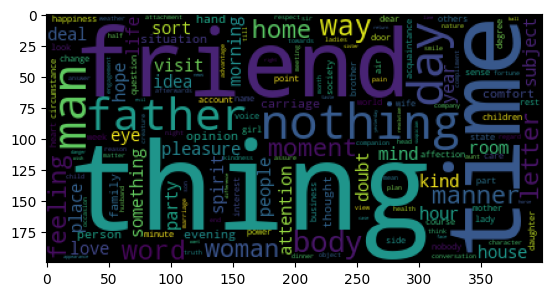

In [28]:
from wordcloud import WordCloud
from matplotlib import pyplot as plt
wordc = WordCloud()
wordc.generate(emma_noun)
plt.imshow(wordc)
plt.show()

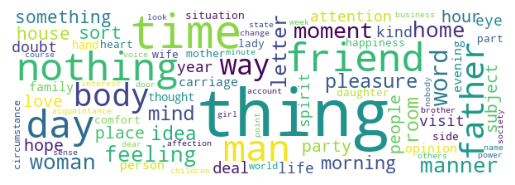

In [29]:
wordcloud = WordCloud(# font_path='',
                    width=600, # 생성될 이미지 가로(픽셀)
                    background_color='white', # 배경색
                    max_words=300, # 표시될 단어의 최대갯수
                    relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                    colormap='viridis', # 글씨 컬러맵
                    max_font_size=80, #최대 폰트 사이즈
                    min_font_size=10  #최소 사이즈
)
wordcloud.generate(emma_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [32]:
# 한글 말뭉치 data로 워드클라우드 시각화
from konlpy.tag import Hannanum, Kkma, Komoran, Okt
from mecab      import MeCab
analyzer = MeCab()
noun_list = analyzer.nouns(data)
noun_list = [word for word, tag in analyzer.pos(data) \
              if tag in ('NNG', 'NNP')]
data_noun = ' '.join(noun_list)
data_noun[:100]

'대한민국 헌법 역사 전통 국민 운동 건립 대한민국 임시 정부 법통 불의 항거 민주 이념 계승 조국 민주 개혁 평화 통일 사명 입각 정의 인도 동포 애 민족 단결 사회 폐습 불의 타'

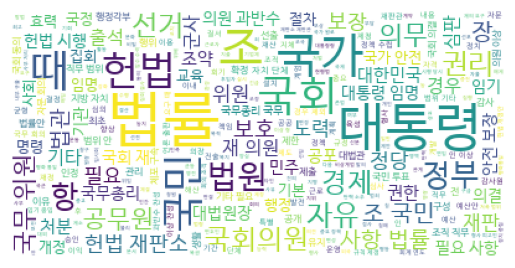

In [37]:
wordcloud = WordCloud(
                font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf',
                # width=800, # 생성될 이미지 가로(픽셀)
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최대갯수
                #relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis', # 글씨 컬러맵
                #random_state=3
)
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [38]:
# 불요어 처리(불용어 지정 + 불용어 사전)
from wordcloud import STOPWORDS
불용어 = STOPWORDS | {'대통령', '법률'}
불용어 = set(['대통령', '법률'])
불용어

{'대통령', '법률'}

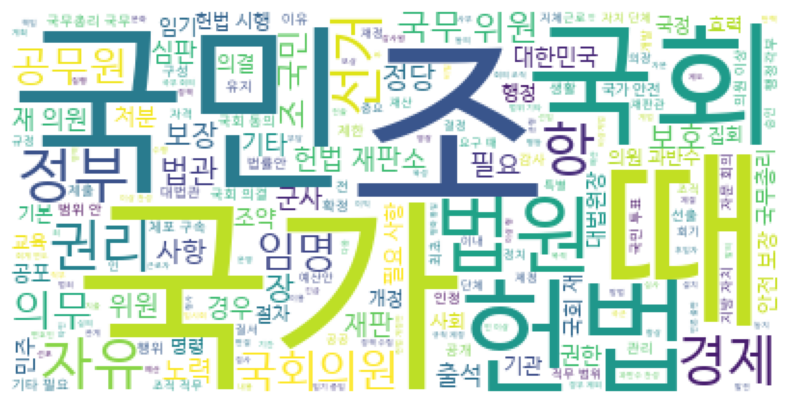

In [39]:
wordcloud = WordCloud(
                font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf',
                # width=800, # 생성될 이미지 가로(픽셀)
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최대갯수
                #relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis', # 글씨 컬러맵
                #random_state=3,
                stopwords=불용어,
                mask =  
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

(468, 720, 3)

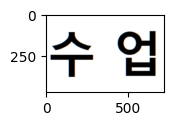

In [42]:
# 마스킹 : 워드클라우드를 지정된 마스크 이미지에 맞도록 설정
# 이미지를 넘파이 배열로 방법
import cv2
# pip install opencv-contrib -pytjon
mask = cv2.imread('data/test.png')
plt.figure(figsize=(2,1))
plt.imshow(mask)
mask.shape

(468, 720, 3)

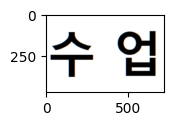

In [47]:
# 이미지를 넘파이 배열로 방법2
import cv2
# %pip install opencv-contrib-python
mask = cv2.imread('data/test.png'
                 # , cv2.IMREAD_GRAYSCALE
                 )
plt.figure(figsize=(2,1))
plt.imshow(mask)
mask.shape

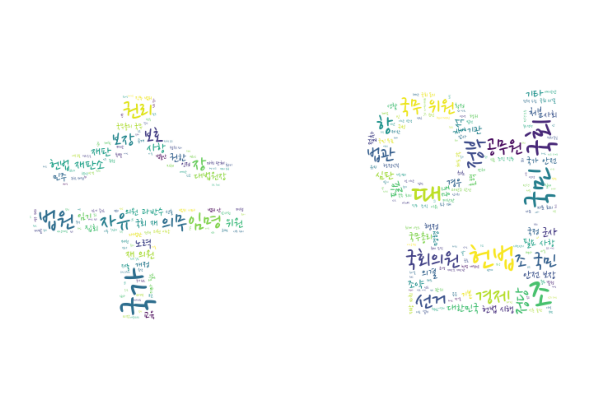

In [48]:
wordcloud = WordCloud(
                #font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf',
                font_path='data/NanumPenScript-Regular.ttf',
                # width=800, # 생성될 이미지 가로(픽셀)
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최대갯수
                #relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis', # 글씨 컬러맵
                #random_state=3,
                stopwords=불용어,
                mask=mask
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [46]:
mask2 = cv2.imread('data/heart.jpg')
mask2.shape

(1600, 1600, 3)

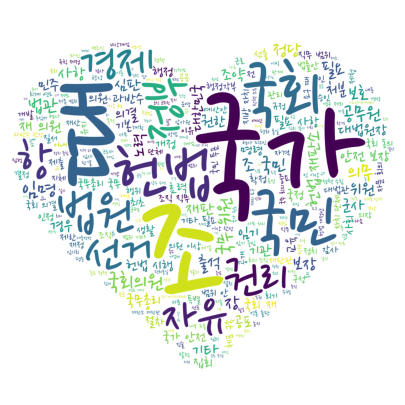

In [53]:
mask2 = cv2.imread('data/heart.jpg')
# plt.figure(figsize=(2,2))
# plt.imshow(mask2)
# mask2.shape
wordcloud = WordCloud(
                #font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf',
                font_path='data/NanumPenScript-Regular.ttf',
                # width=800, # 생성될 이미지 가로(픽셀)
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최대갯수
                #relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis', # 글씨 컬러맵
                #random_state=3,
                stopwords=불용어,
                mask=mask2
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

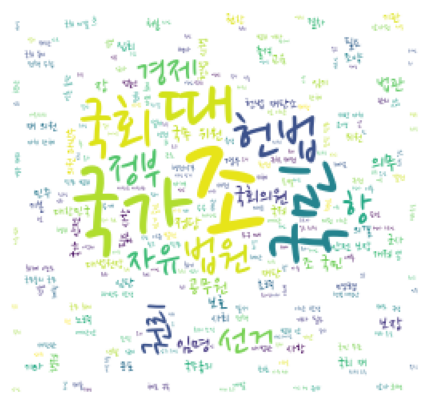

In [55]:
mask3 = cv2.imread('data/test2.jpg')
wordcloud = WordCloud(
                #font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf',
                font_path='data/NanumPenScript-Regular.ttf',
                # width=800, # 생성될 이미지 가로(픽셀)
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최대갯수
                #relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis', # 글씨 컬러맵
                #random_state=3,
                stopwords=불용어,
                mask=mask3
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

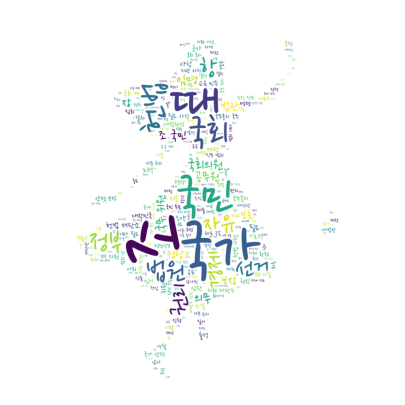

In [56]:
mask4 = cv2.imread('data/test3.png')
mask4.shape
wordcloud = WordCloud(
                #font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf',
                font_path='data/NanumPenScript-Regular.ttf',
                # width=800, # 생성될 이미지 가로(픽셀)
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최대갯수
                #relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis', # 글씨 컬러맵
                #random_state=3,
                stopwords=불용어,
                mask=mask4
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

(1124, 720, 3)


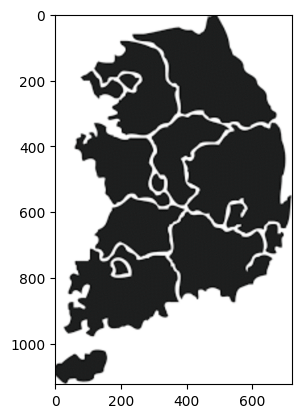

In [61]:
# convert('RGB') : 1채널이미지 ->3채널
# convert('RGBA') : 1채널이미지 -> 4채널(RGB+투명도채널)
from PIL import Image
import numpy as np
img = Image.open('data/south_korea.png').convert('RGB')
mask5 = np.array(img)
print(mask5.shape)
plt.imshow(mask5)

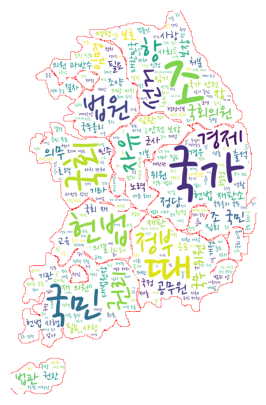

In [62]:
wordcloud = WordCloud(
                #font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf',
                font_path='data/NanumPenScript-Regular.ttf',
                # width=800, # 생성될 이미지 가로(픽셀)
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최대갯수
                #relative_scaling=0.9, # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis', # 글씨 컬러맵
                #random_state=3,
                stopwords=불용어,
                mask=mask5,
                contour_color='red',
                contour_width=1
)
wordcloud.generate(data_noun)
plt.figure(figsize=(18,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

# 단어의 빈도수 시각화

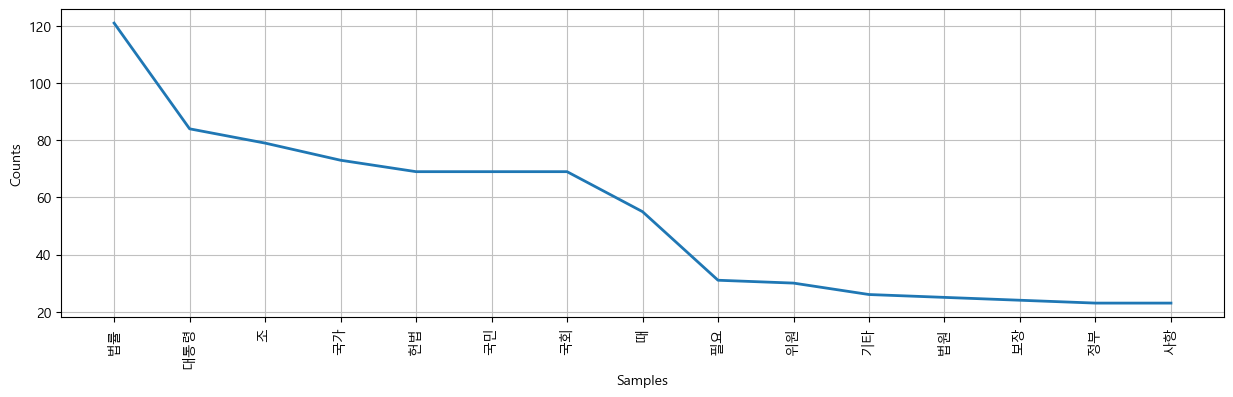

In [66]:
import nltk
data_text = nltk.Text(noun_list)
plt.figure(figsize=(15,4))
plt.rc('font', family="Malgun Gothic")
data_text.plot(15)
plt.show()

## 6 워드 임베딩


In [2]:
import requests
from bs4 import BeautifulSoup
rss_url = 'https://fs.jtbc.co.kr/RSS/economy.xml'
jtbc_response = requests.get(rss_url)
soup = BeautifulSoup(jtbc_response.content, "xml")
link_el = soup.select('item link')
link_list = [el.text for el in link_el]
print(len(link_list))

20


In [3]:
'''각 link들의 뉴스 기사 -> 명사만 : 
  [['드촌', '재건축', '명사1', .....],
   ['캠핑장', '재건축', '명사2', ....], ...]  
'''
from konlpy.tag import Kkma
kkma = Kkma()
news = []
for link in link_list:
    response = requests.get(link)
    # print(response.status_code)
    news_soup = BeautifulSoup(response.content, "html.parser")
    title = news_soup.select_one('title').text
    description = str(news_soup.select_one('meta[name="description"]'))
    noun_list = kkma.nouns(title + ' ' + description)
    불용어 = {'뉴스','앵커'}
    noun_list = [word for word in noun_list if word not in 불용어]
    #print(noun_list)
    news.append(noun_list)

In [4]:
# rss의 title과 description => 명사 추출 => 워드임베딩(단어간 거리 계산) => 특정 단어의 유사도
import requests
from bs4 import BeautifulSoup
from konlpy.tag import Kkma
kkma = Kkma()
rss_url = 'https://fs.jtbc.co.kr/RSS/economy.xml'
jtbc_response = requests.get(rss_url)
soup = BeautifulSoup(jtbc_response.content, "xml")
news = []
item_elems = soup.find_all('item')
for item_elem in item_elems:
    title = item_elem.find('title').text
    description = item_elem.find('description').text
    #print(title + ' ' + description)
    article = title + ' ' + description.replace('[앵커]',' ')
    noun_list = kkma.nouns(article)
    # 보통명사(NNG), 고유명사(NNP)
    noun_list = [word for word, tag in kkma.pos(article) if tag in ('NNG','NNP')]
    news.append(noun_list)
print(news[:3])

[['촌', '주공', '전', '홍수', '예상', '눈치', '게임', '시작', '단군', '이래', '최대', '규모', '건축', '불리', '촌', '주공', '아파트', '입주', '다음', '말', '시작', '대규모', '입주', '전세', '매물', '현장', '분위기', '이'], ['실제', '완전', '사기', '캠핑', '장', '관리', '소홀', '캠핑', '장', '예약', '때', '예약', '플랫폼', '사진', '실제', '불만', '경우', '앞', '예약', '플랫폼', '책임', '강화', '아람', '기자', '기자', '인터넷', '카페'], ['요즘', '끼', '편의점', '정도', '일', '줄', '육박', '점심', '값', '편의점', '도시락', '끼', '때', '편의점', '도시락', '식비', '부담', '아람', '기자', '기자', '서울', '한']]


In [ ]:
# 워드 임베딩 (단어간 거리 계산)
!pip install gensim
from gensim.models import Word2Vec
model = Word2Vec(news, # 학습데이터 2차원
                window=10, # 각 단어의 좌우10개 단어를 학습 컨텐츠로 사용
                min_count=2, # 학습데이터에서 2회 이상 등장한 단어만 학습.
                workers=-1  # 병렬처리 core수. -1:모든 가용 코어 사용
                )

In [ ]:
model.wv.most_similar('아파트')

In [ ]:

model.wv.most_similar('아파트', topn=3)